# 11.2.1 每条边的交换与守恒

## 学习目标与先修知识

从边收支（mass balance）推导图拉普拉斯（graph Laplacian）并检查总量守恒。

先修：11.1 邻接与分量；3.3 多室交换；2.2 变化率。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

在细胞或室之间的对称交换边上，物质从高浓度（concentration）流向低浓度。若只在发送节点扣除而忘记接收节点，总量就会凭空消失。如何逐边组织所有节点的收支？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

对 0—1—2 链，分别写出两条边给矩阵（matrix）的四个非零位置。

In [2]:
print('0—1率2：[[+2,-2,0],[-2,+2,0],[0,0,0]]；1—2率1再加同型块。')

0—1率2：[[+2,-2,0],[-2,+2,0],[0,0,0]]；1—2率1再加同型块。


## 模型假设

边无向、交换系数非负、两端对称；每个节点容积均取共同值 $V_0=1$ V。$x_i$ 表示节点所追踪物质总量（tracked amount），单位 U；浓度 $c_i=x_i/V_0$，在所选 U、V 单位下与 $x_i$ 数值相同。本节的归一化边系数 $k_{ij}$ 单位为 1/T，边总量流率（flow rate）为 $k_{ij}(x_i-x_j)$，单位 U/T。没有外部输入（input）输出（output）；下一节再区分非等容积时的总量、浓度与物理交换系数。

## 数学解释与推导

一条边 $(i,j)$ 的总量流率（flow rate）为 $k_{ij}(x_i-x_j)$，在节点 $i$ 的变化率贡献 $-k_{ij}(x_i-x_j)$，节点 $j$ 为其相反数。把全部边相加得 $\dot x=-L_kx$，其中 $(L_k)_{ii}=\sum_{j\ne i}k_{ij}$，$(L_k)_{ij}=-k_{ij}$，$[k_{ij}]=1/T$。$L_k$ 对称，$L_k\mathbf1=0$；由于对称，也有 $\mathbf1^\mathsf TL_k=0$，故 $d(\mathbf1^\mathsf Tx)/dt=0$。这是明确假设下的总量守恒，不可直接把有向非对称算子照搬。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def laplacian(n, weighted_edges):
    """Symmetric exchange operator; an edge is [i,j,rate]."""
    import numpy as np
    matrix = np.zeros((n, n), dtype=float)
    for i, j, rate in weighted_edges:
        matrix[i, i] += rate
        matrix[j, j] += rate
        matrix[i, j] -= rate
        matrix[j, i] -= rate
    return matrix.tolist()


def diffuse_amounts(n, weighted_edges, initial, volumes, dt, steps):
    """Forward Euler for dm/dt=-L(m/V); returns initial and subsequent amounts."""
    import numpy as np
    operator = np.asarray(laplacian(n, weighted_edges), dtype=float)
    volume = np.asarray(volumes, dtype=float)
    amount = np.asarray(initial, dtype=float)
    history = [amount.tolist()]
    for _ in range(steps):
        amount = amount - dt * (operator @ (amount / volume))
        history.append(amount.tolist())
    return history

## 对照实验

在三室链中把 3 U 全放在左端，显式更新到 8 T，显示各室与总量。

L= [[ 1.  -1.   0. ]
 [-1.   1.5 -0.5]
 [ 0.  -0.5  0.5]] 初末总量= 3.0 3.0000000000000027


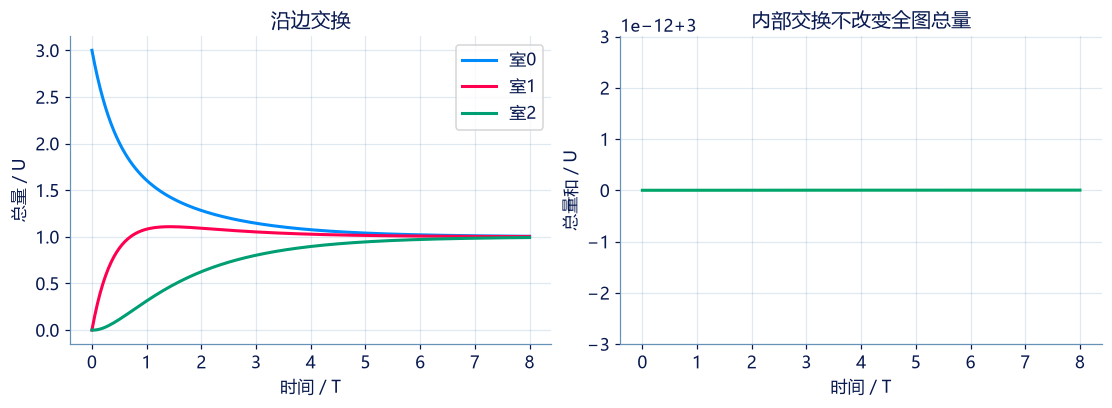

In [4]:
edges = [[0,1,1.], [1,2,.5]]
L = np.array(laplacian(3,edges))
history = np.array(diffuse_amounts(3,edges,[3.,0.,0.],[1.,1.,1.],.05,160))
print('L=',L,'初末总量=',history[0].sum(),history[-1].sum())
fig, axes = plt.subplots(1, 2, figsize=(10,3.6))
for i in range(3): axes[0].plot(np.arange(len(history))*.05,history[:,i],label=f'室{i}')
axes[0].set(xlabel='时间 / T',ylabel='总量 / U',title='沿边交换');axes[0].legend()
axes[1].plot(np.arange(len(history))*.05,history.sum(axis=1),color=GREEN)
axes[1].set(xlabel='时间 / T',ylabel='总量和 / U',title='内部交换不改变全图总量');plt.show()

## 结果解释

左室下降、另两室上升，指的是节点间转移。总量曲线近乎水平是模型（model）边收支与数值实现共同应满足的检查；它不自动证明时间步足够小或每室始终非负。

### 独立核对

用手算矩阵、对称性和行列和作独立核对；逐时总量只在浮点容差内相等。

In [5]:
np.testing.assert_allclose(L, [[1,-1,0],[-1,1.5,-.5],[0,-.5,.5]])
np.testing.assert_allclose(L,L.T)
np.testing.assert_allclose(L.sum(axis=0),np.zeros(3),atol=1e-12)
np.testing.assert_allclose(history.sum(axis=1),3.,atol=1e-10)
assert history.min() >= -1e-12
print('逐边矩阵、对称性、守恒与非负性均通过。')

逐边矩阵、对称性、守恒与非负性均通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/11-02-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E6%89%A9%E6%95%A3%E4%B8%8E%E5%AE%88%E6%81%92/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：由交换边构造拉普拉斯

每项 [i,j,rate] 是归一化的对称交换率 k_ij（单位1/T）。构造 L_k，使等容积总量模型（model）的变化率为 −L_k m；边贡献 L_ii+=rate、L_jj+=rate、L_ij−=rate、L_ji−=rate。

**函数与代码模板**

```python
def solve(
    n: int,
    weighted_edges: list[list[float]],
) -> list[list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `n` | `int` | 节点数。 | 个 |
| `weighted_edges` | `list[list[float]]` | 每条无向边的两端编号与非负归一化交换率 k_ij。 | 1/T |

**返回值**

直接返回 L（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `L` | `list[list[float]]` | n×n 对称拉普拉斯矩阵（matrix）。 | 1/T |

**计算规则**

同一无向边只给一次；孤立节点保留全零行。

**约束与边界**

- 只计算题定有限图和数值模型；返回普通 Python 列表、数值或元组。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| n | 节点数。 | 3 | 个 |
| weighted_edges | 每条无向边的两端编号与非负归一化交换率 k_ij。 | [[0, 1, 2.0], [1, 2, 1.0]] | 1/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
n = 3
weighted_edges = [[0, 1, 2.0], [1, 2, 1.0]]

result = solve(n, weighted_edges)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| L | n×n 对称拉普拉斯矩阵（matrix）。 | [[2.0, -2.0, 0.0], [-2.0, 3.0, -1.0], [0.0, -1.0, 1.0]] | 1/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[2.0, -2.0, 0.0],
                   [-2.0, 3.0, -1.0],
                   [0.0, -1.0, 1.0]]
```

**样例解释**

首例的行和全为0；第一条边给(0,1)与(1,0)各减去2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：由交换边构造拉普拉斯](http://127.0.0.1:8000/chapters/11-02-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E6%89%A9%E6%95%A3%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p11-exchange-laplacian)

### 第 2 题 · 单项选择题：一条边的收支

两等容积节点以 rate·(x_i−x_j) 从 i 流向 j。哪组变化率守恒？

- **A.** 节点i为−rate(x_i−x_j)，节点j为+rate(x_i−x_j)。
- **B.** 两个节点都为−rate(x_i−x_j)。
- **C.** 只更新i而不更新j。
- **D.** 无向交换可产生外部输入（input）。

[作答：一条边的收支](http://127.0.0.1:8000/chapters/11-02-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E6%89%A9%E6%95%A3%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p11-edge-conservation)

### 第 3 题 · 单项选择题：有向边不能偷换算子

一个有向非对称传播矩阵（matrix）的行和为0。能否直接套用本章无向 L 的实特征值（eigenvalue）和正交（orthogonality）模态（mode）结论？

- **A.** 能，因为只要行和为0就足够。
- **B.** 不能；守恒还需检查合适的列和，正交谱分解也依赖对称性。
- **C.** 能，因为绘图里箭头可忽略。
- **D.** 能，因为所有矩阵的特征向量（eigenvector）都正交。

[作答：有向边不能偷换算子](http://127.0.0.1:8000/chapters/11-02-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E6%89%A9%E6%95%A3%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p11-directed-warning)

### 第 4 题 · 单项选择题：孤立节点的零模态

一个图有两个互不连接的分量，所有边为正对称交换。长期状态（state）的正确描述是什么？

- **A.** 全图必达到一个共同平均值。
- **B.** 每个连通分量（connected component）各自保留初始总量并趋向本分量平均值。
- **C.** 孤立分量的总量会流入另一分量。
- **D.** 只有一个零模态（mode）。

[作答：孤立节点的零模态](http://127.0.0.1:8000/chapters/11-02-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E6%89%A9%E6%95%A3%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p11-zero-mode)

**进一步阅读**

[NetworkX 官方图矩阵索引](https://networkx.org/documentation/stable/reference/linalg.html)定义图拉普拉斯；本节逐边构造以显露物质收支。